# MATH 440 — Final Project
## Model Selection from Curated Datasets

**Name:** [Eren Onat]
**Date submitted:** [4/28/2026]  
**Dataset:** [DS14 Dungeness Crab Cohort Biomass, US Pacific Coast, USA]

---
> **Before submitting:**
> - Replace every `[placeholder]` with your own content.
> - The notebook must run top-to-bottom without errors: Kernel → Restart and Run All.
> - Delete all scratch cells.
> - Filename: `LastName_FirstName_FinalProject.ipynb`

---
## Imports and Global Settings

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Use Numpy's modern RNG (for the bootstrap in Step 5)
rng = np.random.default_rng(2026)

# Golden-ratio figure dimensions (inches)
golden_ratio = (1 + 5**0.5) / 2
FIG_HEIGHT = 5
FIG_WIDTH = FIG_HEIGHT * golden_ratio

# Specify font size and figure quality for all figures
plt.rcParams.update({'font.size': 11, 'figure.dpi': 300})

## Data and Configuration
Define your data file path and any fixed parameter values here.

In [76]:
# Load your data
DATA_FILE = 'DS14.csv'  # dataset for this project

# Fixed parameters from scenario card (examples). Leave as None if not used.
THETA_FIXED = 0.7
C_FIXED = None

# Load the dataset using pandas
df = pd.read_csv(DATA_FILE)
print("Column names: ", df.columns.tolist())  # shows the actual column names
print(df.head())  # quick sanity check

t_data = df.iloc[:, 0].to_numpy(dtype=float)   # column 0 = time
y_data = df.iloc[:, 1].to_numpy(dtype=float)   # column 1 = QOI
n_obs = len(y_data)
N0 = float(y_data[0])

print(f'Dataset: {DATA_FILE}')
print(f'Observations: n = {n_obs}')
print(f'Time range: {t_data[0]:.4g} to {t_data[-1]:.4g}')
print(f'QOI range: {y_data.min():.4g} to {y_data.max():.4g}')
print(f'Initial value: N(0) ≈ {y_data[0]:.4g}')

Column names:  ['year', 'cohort_biomass_mt']
   year  cohort_biomass_mt
0     0              138.0
1     1              246.0
2     2              528.0
3     3              940.0
4     4              913.0
Dataset: DS14.csv
Observations: n = 55
Time range: 0 to 54
QOI range: 138 to 1.194e+04
Initial value: N(0) ≈ 138


---
## Step 2. Analyze (Raw data plot)

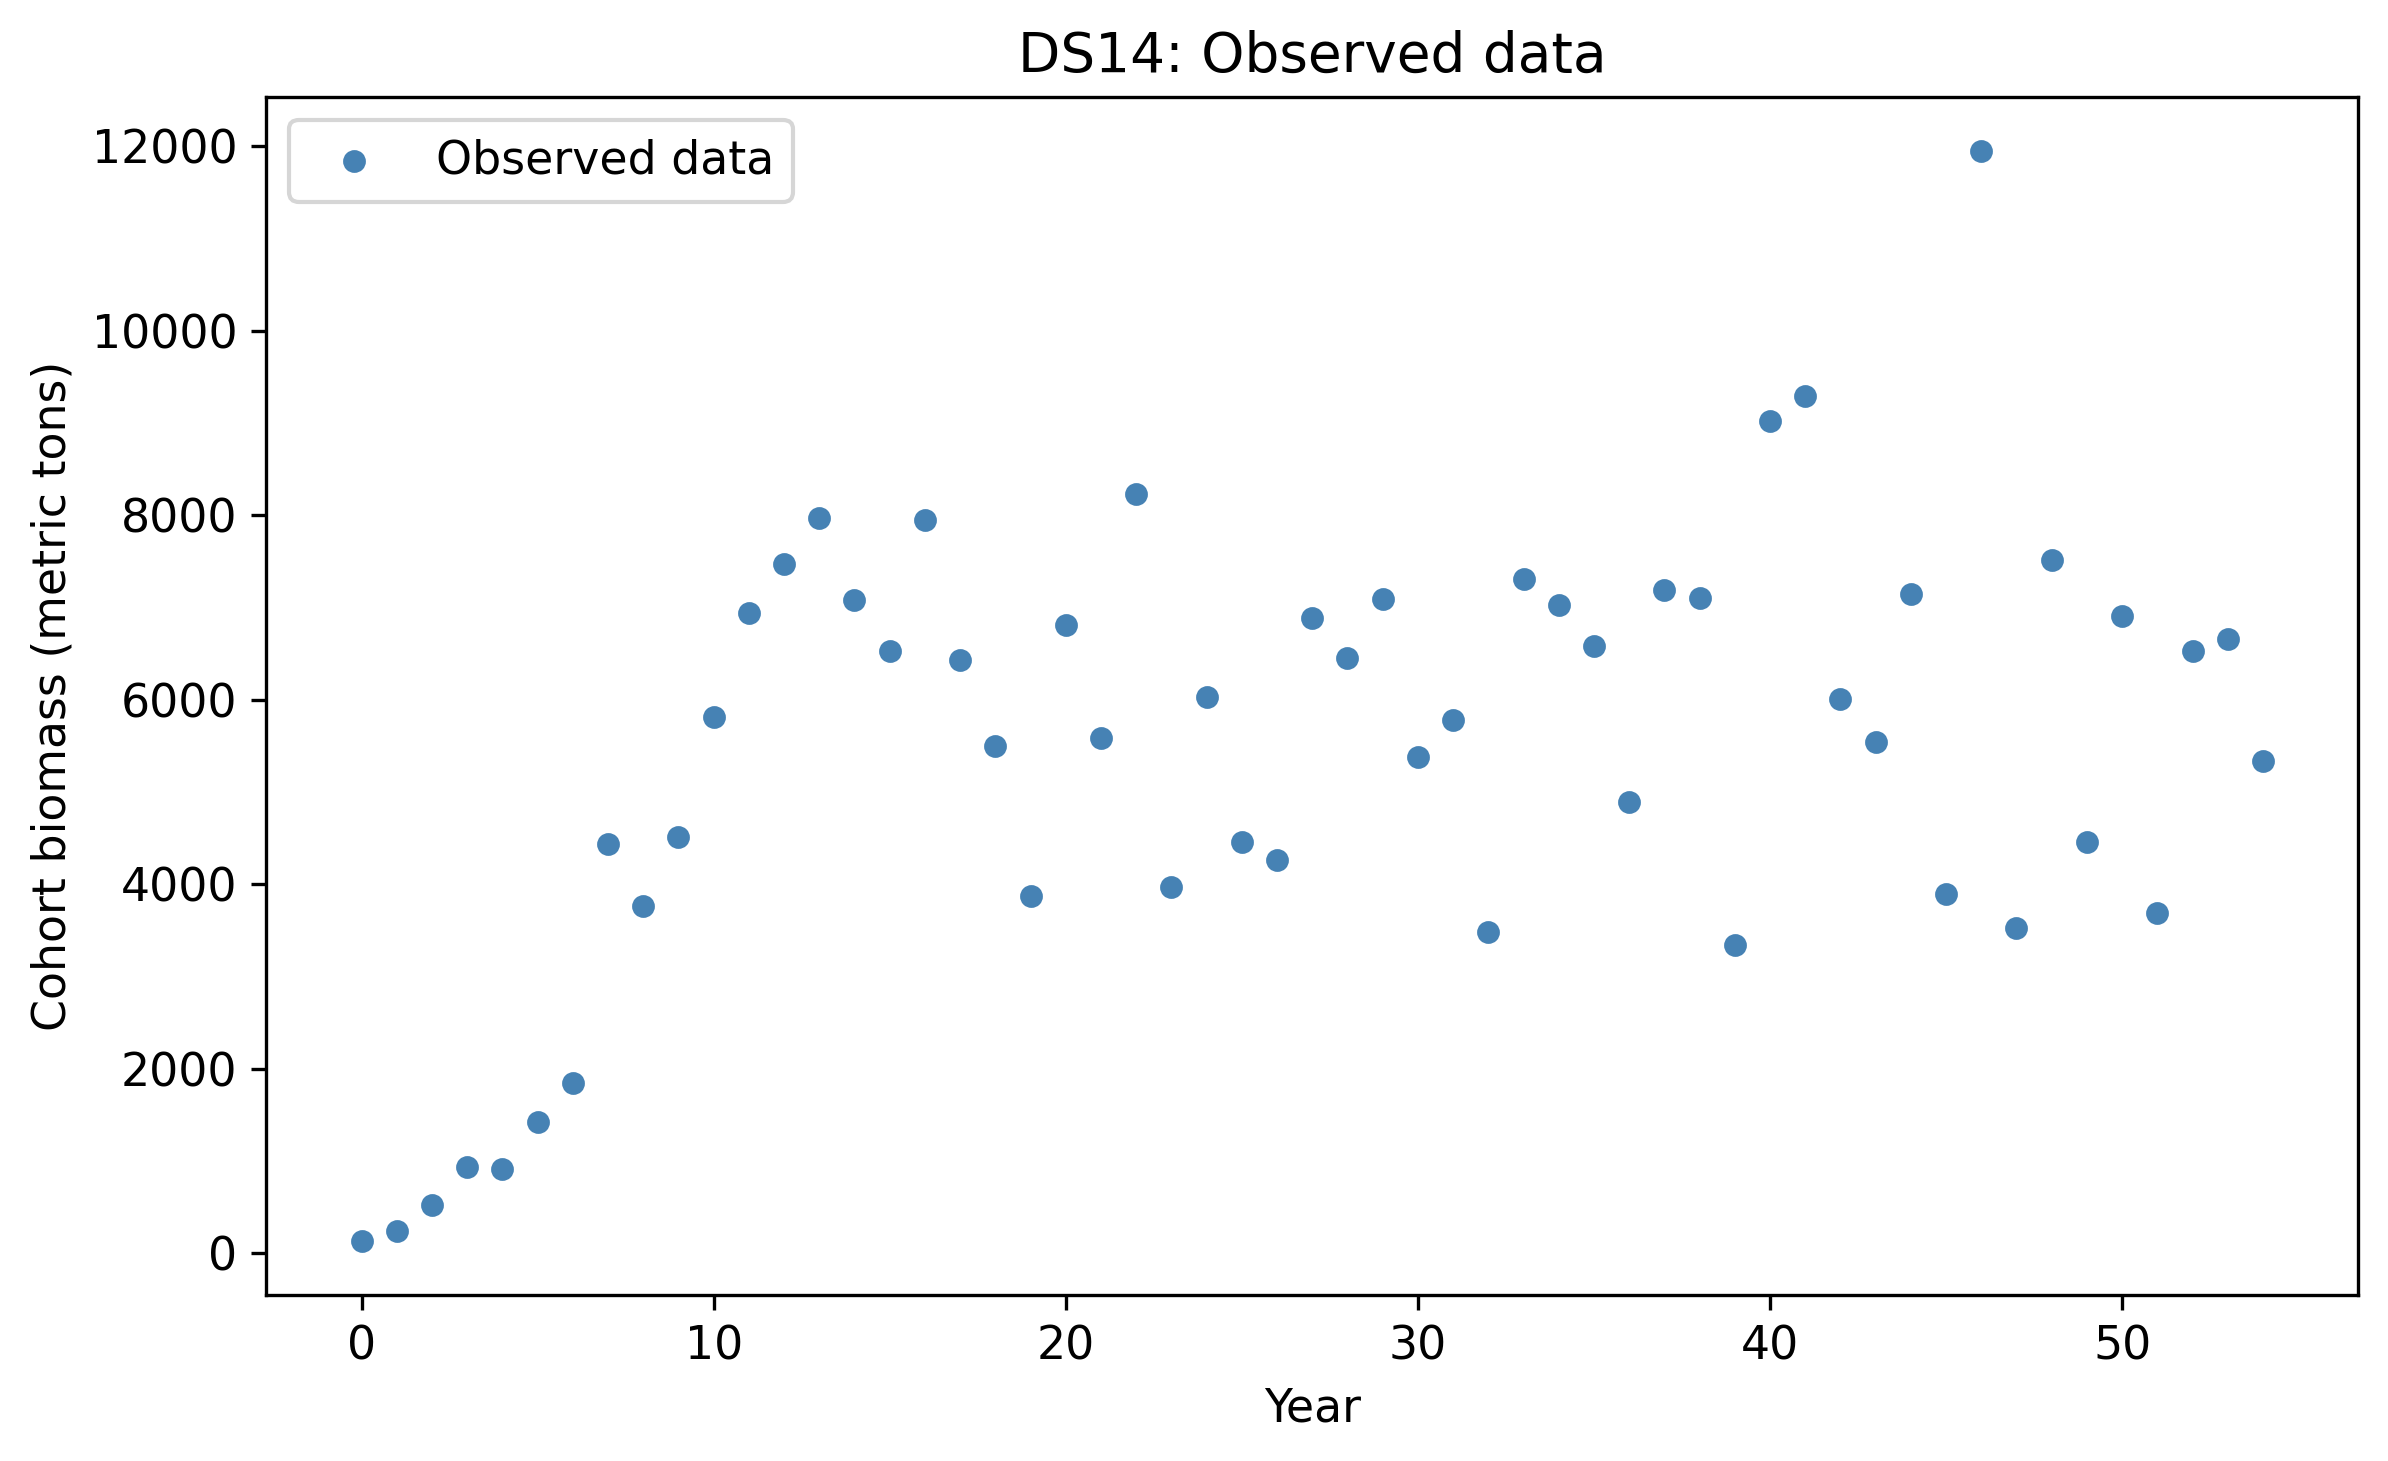

In [77]:
# Raw Data Plot

plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
plt.scatter(t_data, y_data, s=20, color='steelblue', label='Observed data')
plt.xlabel('Year')   
plt.ylabel('Cohort biomass (metric tons)')             
plt.title('DS14: Observed data')  
plt.legend()
plt.tight_layout()
plt.savefig('DS14.png')
plt.show()

---
## Step 3. Simulate and Fit

### How to write a model function

`curve_fit` calls your function as `f(t, param1, param2, ...)` and
expects an array of predicted values back.  The **logistic model** is used
in all three examples below so you can compare the patterns directly.
Write the closed-form solution whenever it exists.

**Pattern 1: Closed-form analytical solution (logistic):**
```python
def model_logistic_analytical(t, r, K):
    # N(t) = K / (1 + ((K - N0)/N0) * exp(-r*t))
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))
```

**Pattern 2: Continuous ODE via solve_ivp (same logistic, no closed form assumed):**
```python
def model_logistic_ode(t, r, K):
    def rhs(s, N):
        return [r * N[0] * (1 - N[0] / K)]   # dN/dt = r*N*(1 - N/K)
    sol = solve_ivp(rhs, [t[0], t[-1]], [N0], t_eval=t)
    return sol.y[0]
```

**Pattern 3: Discrete map via for-loop (discrete logistic):**
```python
def model_logistic_discrete(t, r, K):
    N = np.zeros(len(t))
    N[0] = N0
    for i in range(len(t) - 1):
        N[i+1] = N[i] * (1 + r * (1 - N[i] / K))
    return N
```

### Key lessons for fitting

1. Initial guess for $K$: use `y_data.max() * 1.5`, not `y_data.max()`.
   If the data have not yet reached the plateau, `max(data)` underestimates $K$
   and the optimizer can get stuck.
2. Initial guess for $N(0)$: use `y_data[0]` (the actual first observed value).
3. Bounds enforce physical constraints: carrying capacity must exceed the
   observed maximum; rates must be positive.
4. `maxfev=10000` gives the optimizer enough iterations for models
   that are expensive to evaluate (ODE-based or discrete).

### Model functions

In [78]:
# Example model patterns are described in the markdown above.
# The actual DS14 model functions are defined below in the notebook.

In [79]:
# DS14 uses annual discrete-time biomass data, so each model returns the full simulated trajectory.
# The common starting value is the first observed biomass.
N0 = float(y_data[0])

# Model 1: Discrete logistic
# N[t+1] = N[t] * (1 + r * (1 - N[t] / K))
def model1_logistic(t, r, K):
    N = np.zeros(len(t), dtype=float)
    N[0] = N0
    for i in range(len(t) - 1):
        N[i + 1] = N[i] * (1 + r * (1 - N[i] / K))
    return N

# Model 2: Smith-Slatkin discrete
# N[t+1] = N[t] * exp(r) / (1 + (exp(r) - 1) * N[t] / K)
def model2_smith_slatkin(t, r, K):
    N = np.zeros(len(t), dtype=float)
    N[0] = N0
    R = np.exp(r)
    for i in range(len(t) - 1):
        N[i + 1] = (N[i] * R) / (1 + (R - 1) * N[i] / K)
    return N

# Model 3: Beverton-Holt discrete
# N[t+1] = (lambda * N[t]) / (1 + alpha * N[t])
def model3_beverton_holt(t, lam, alpha):
    N = np.zeros(len(t), dtype=float)
    N[0] = N0
    for i in range(len(t) - 1):
        N[i + 1] = (lam * N[i]) / (1 + alpha * N[i])
    return N

# Model 4: Ricker discrete
# N[t+1] = N[t] * exp(r * (1 - N[t] / K))
def model4_ricker(t, r, K):
    N = np.zeros(len(t), dtype=float)
    N[0] = N0
    for i in range(len(t) - 1):
        N[i + 1] = N[i] * np.exp(r * (1 - N[i] / K))
    return N

# Model 5: Theta-Ricker discrete with theta fixed at THETA_FIXED
# N[t+1] = N[t] * exp(r * (1 - (N[t] / K)**theta))
def model5_theta_ricker(t, r, K):
    theta = THETA_FIXED
    N = np.zeros(len(t), dtype=float)
    N[0] = N0
    for i in range(len(t) - 1):
        N[i + 1] = N[i] * np.exp(r * (1 - (N[i] / K) ** theta))
    return N

### Fit Model 1: Logistic

Model 1: Logistic [6.34670982e-02 1.20594000e+04]
Model 2: Smith-Slatkin [7.55788647e-02 1.20594000e+04]
Model 3: Beverton-Holt [5.78785209e+00 7.85752395e-04]
Model 4: Ricker [6.76954472e-02 1.20594000e+04]
Model 5: Theta-Ricker (theta=0.7) [1.17363155e-01 1.20594000e+04]


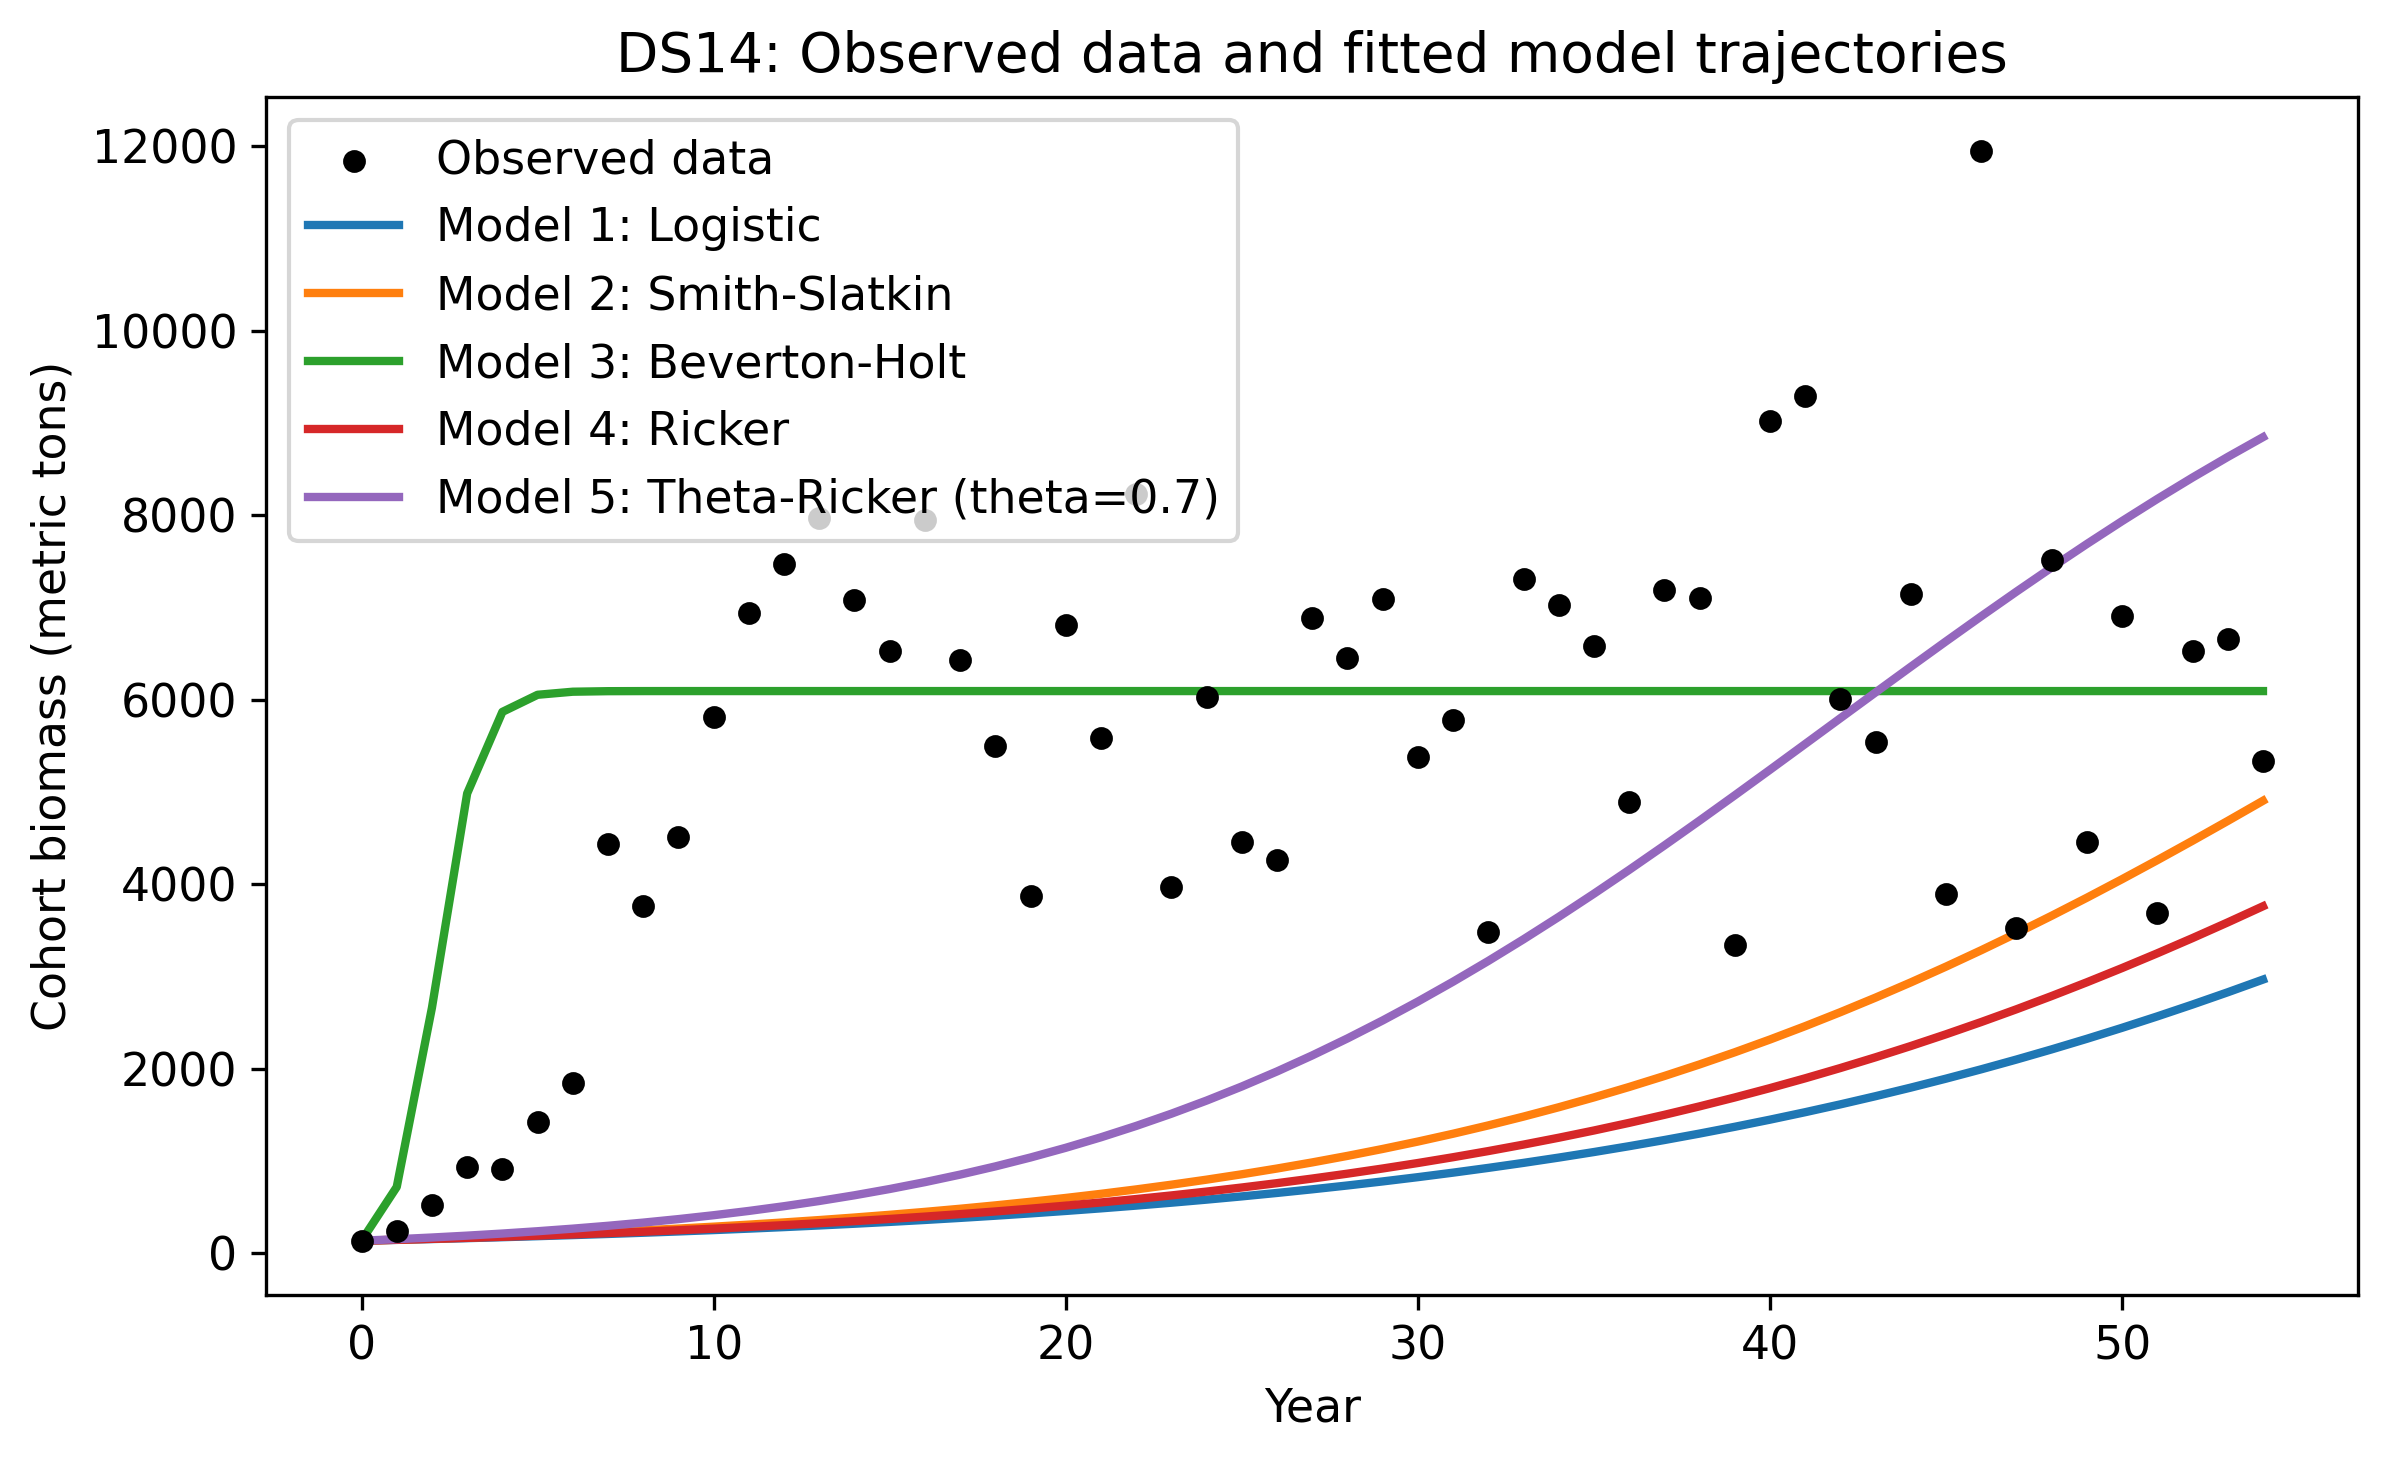

In [80]:
# Fit all five candidate models to the DS14 annual biomass series
x_step = y_data[:-1]
y_step = y_data[1:]

def step1_logistic(Nt, r, K):
    return Nt * (1 + r * (1 - Nt / K))

def step2_smith_slatkin(Nt, r, K):
    R = np.exp(r)
    return (Nt * R) / (1 + (R - 1) * Nt / K)

def step3_beverton_holt(Nt, lam, alpha):
    return (lam * Nt) / (1 + alpha * Nt)

def step4_ricker(Nt, r, K):
    return Nt * np.exp(r * (1 - Nt / K))

def step5_theta_ricker(Nt, r, K):
    return Nt * np.exp(r * (1 - (Nt / K) ** THETA_FIXED))

p0_1 = [0.8, y_data.max() * 1.5]
bounds_1 = ([0.0, y_data.max() * 1.01], [20.0, 1e8])
p0_3 = [1.2, 1.0 / max(y_data.max(), 1.0)]
bounds_3 = ([1e-6, 0.0], [1e3, 1.0])

params_1, _ = curve_fit(step1_logistic, x_step, y_step, p0=p0_1, bounds=bounds_1, maxfev=20000)
params_2, _ = curve_fit(step2_smith_slatkin, x_step, y_step, p0=p0_1, bounds=bounds_1, maxfev=20000)
params_3, _ = curve_fit(step3_beverton_holt, x_step, y_step, p0=p0_3, bounds=bounds_3, maxfev=20000)
params_4, _ = curve_fit(step4_ricker, x_step, y_step, p0=p0_1, bounds=bounds_1, maxfev=20000)
params_5, _ = curve_fit(step5_theta_ricker, x_step, y_step, p0=p0_1, bounds=bounds_1, maxfev=20000)

def simulate_trajectory(step_func, params):
    values = [y_data[0]]
    for _ in range(len(y_data) - 1):
        values.append(step_func(values[-1], *params))
    return np.asarray(values, dtype=float)

ypred_1 = simulate_trajectory(step1_logistic, params_1)
ypred_2 = simulate_trajectory(step2_smith_slatkin, params_2)
ypred_3 = simulate_trajectory(step3_beverton_holt, params_3)
ypred_4 = simulate_trajectory(step4_ricker, params_4)
ypred_5 = simulate_trajectory(step5_theta_ricker, params_5)

model_info = [
    ('Model 1: Logistic', step1_logistic, params_1, ypred_1),
    ('Model 2: Smith-Slatkin', step2_smith_slatkin, params_2, ypred_2),
    ('Model 3: Beverton-Holt', step3_beverton_holt, params_3, ypred_3),
    ('Model 4: Ricker', step4_ricker, params_4, ypred_4),
    (f'Model 5: Theta-Ricker (theta={THETA_FIXED})', step5_theta_ricker, params_5, ypred_5),
]

print('Model 1: Logistic', params_1)
print('Model 2: Smith-Slatkin', params_2)
print('Model 3: Beverton-Holt', params_3)
print('Model 4: Ricker', params_4)
print(f'Model 5: Theta-Ricker (theta={THETA_FIXED})', params_5)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax.scatter(t_data, y_data, s=20, color='black', label='Observed data', zorder=5)
ax.plot(t_data, ypred_1, lw=2, label='Model 1: Logistic')
ax.plot(t_data, ypred_2, lw=2, label='Model 2: Smith-Slatkin')
ax.plot(t_data, ypred_3, lw=2, label='Model 3: Beverton-Holt')
ax.plot(t_data, ypred_4, lw=2, label='Model 4: Ricker')
ax.plot(t_data, ypred_5, lw=2, label=f'Model 5: Theta-Ricker (theta={THETA_FIXED})')
ax.set_xlabel('Year')
ax.set_ylabel('Cohort biomass (metric tons)')
ax.set_title('DS14: Observed data and fitted model trajectories')
ax.legend()
plt.tight_layout()
plt.savefig('step3_super_plot.png', bbox_inches='tight')
plt.show()

### Figure 2: Super Plot

### Figure 3: Top Candidate Model

---
## Step 4. Validate and Select


### Figure 4: Residual Plots

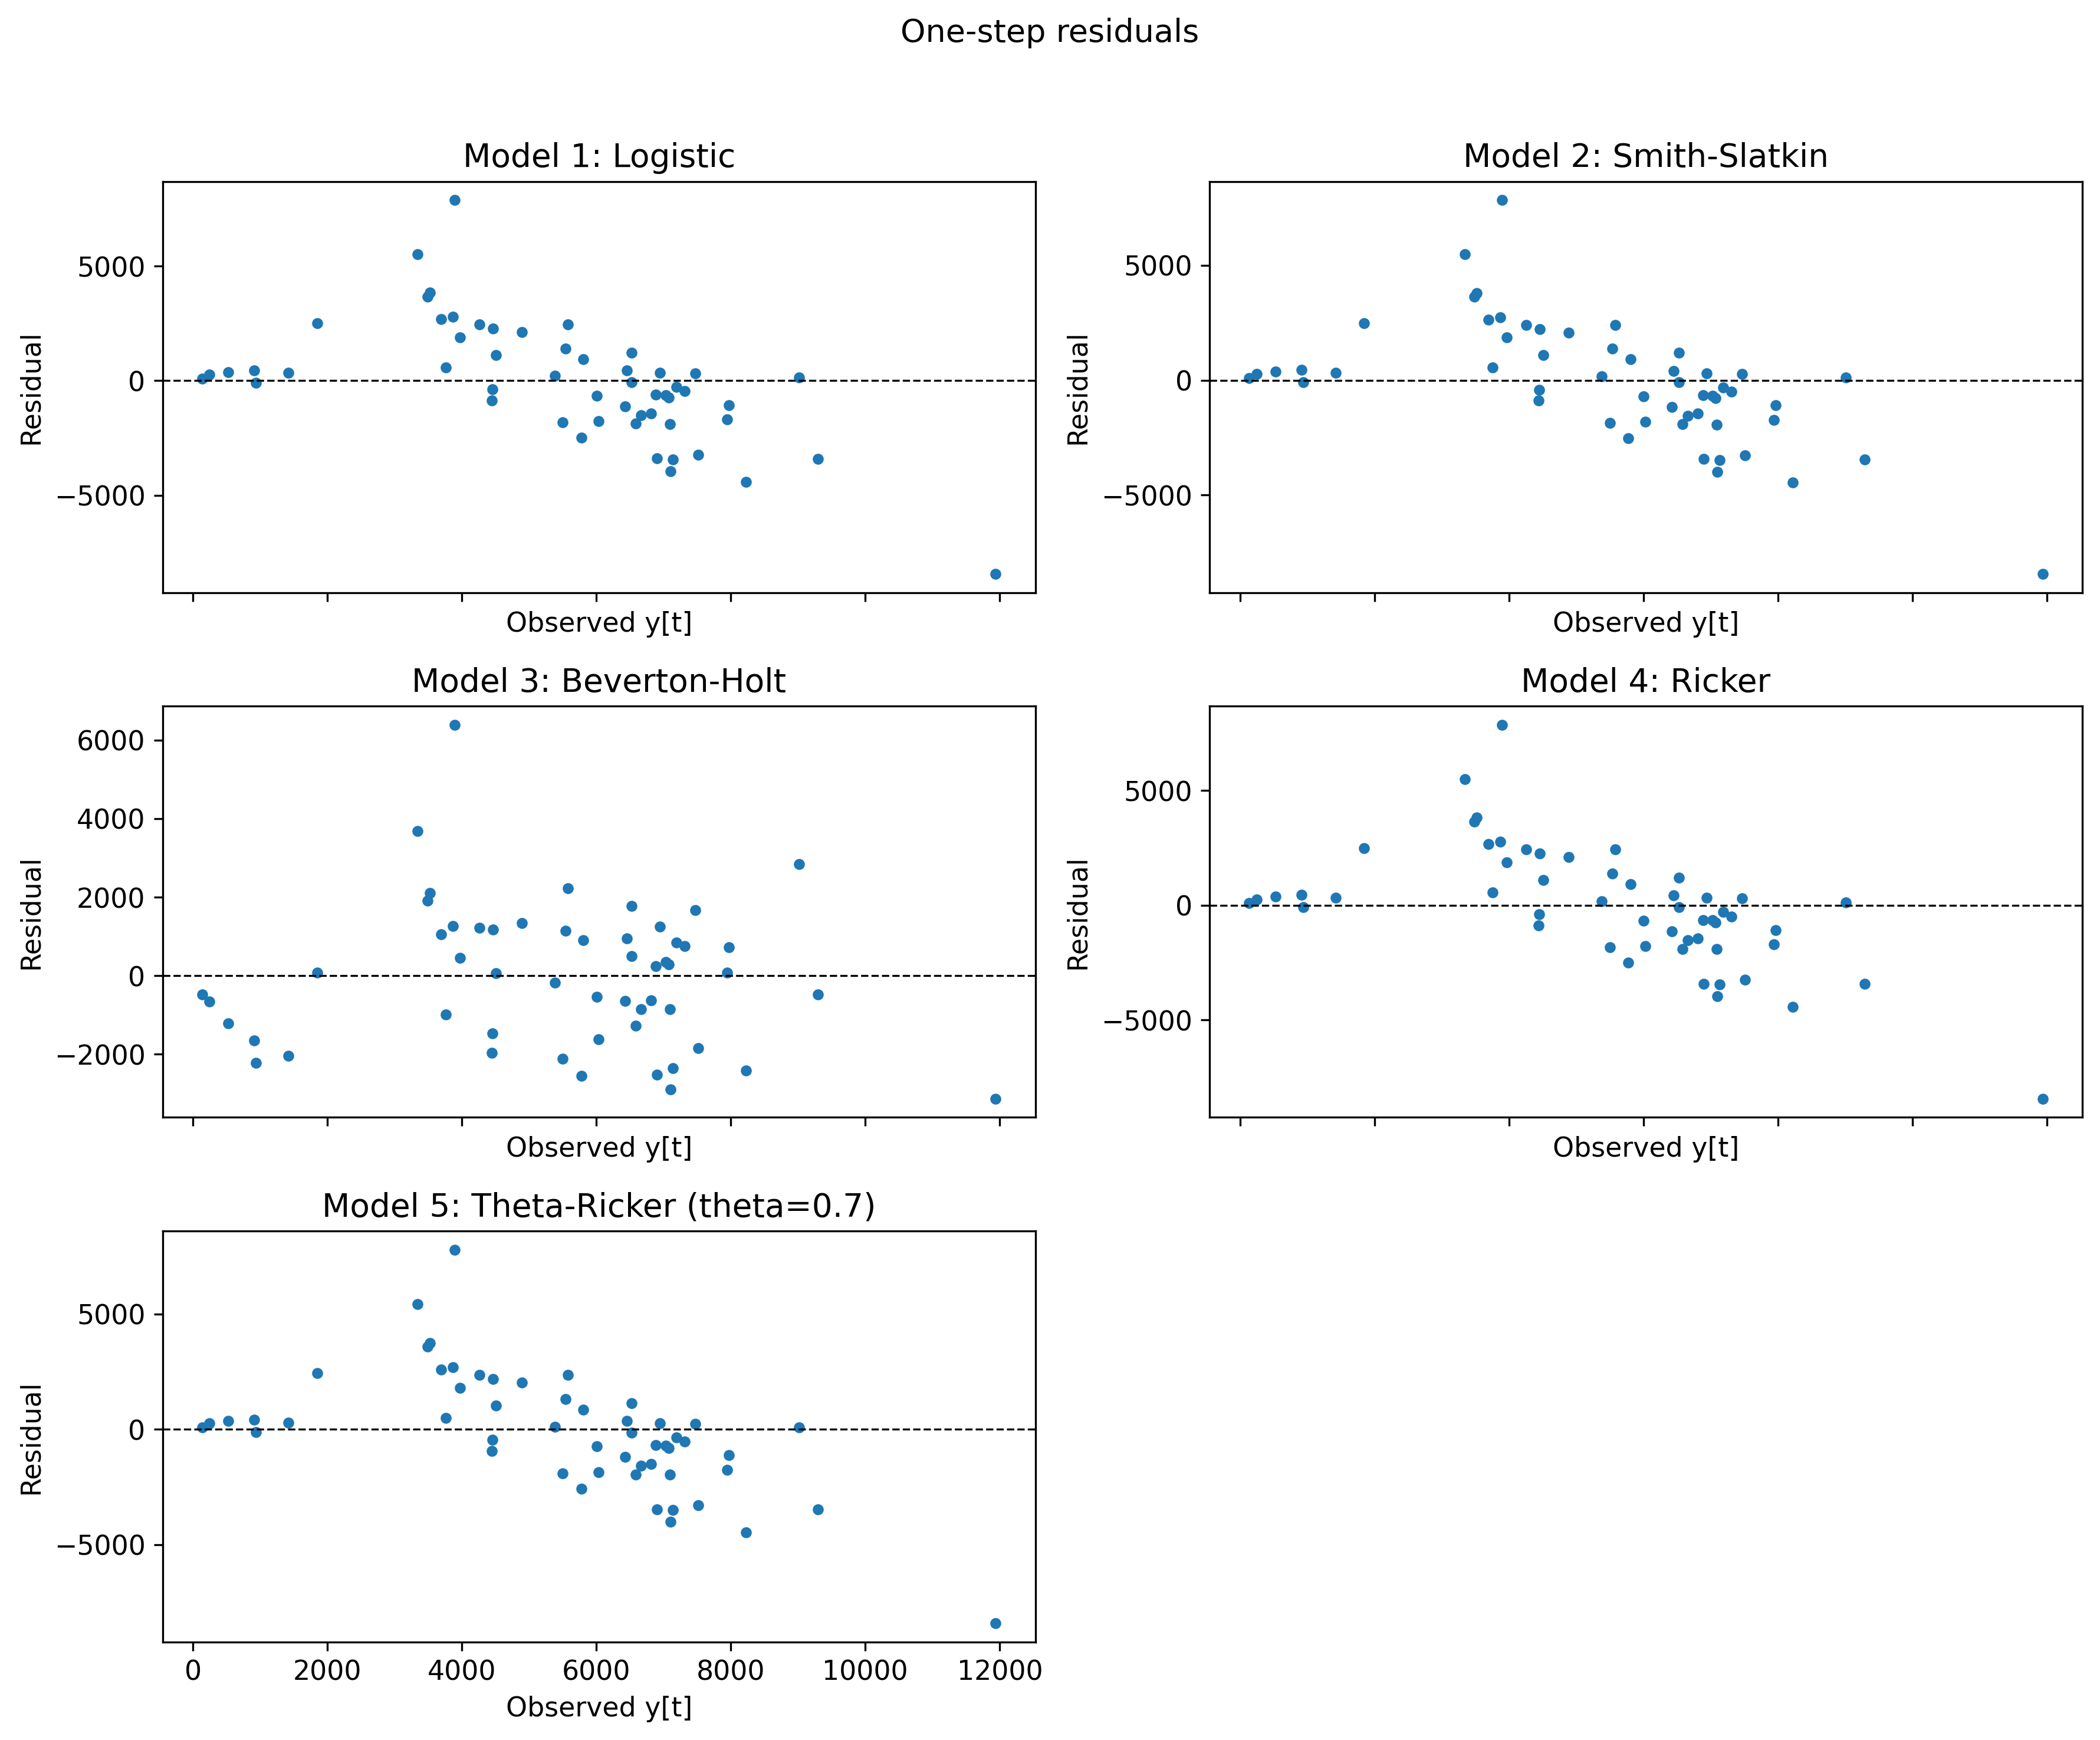

In [81]:
# One-step residual plots for all fitted models
x_step = y_data[:-1]
y_step = y_data[1:]
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

for ax, name, func, params in zip(axes, [item[0] for item in model_info], [item[1] for item in model_info], [item[2] for item in model_info]):
    yhat_step = func(x_step, *params)
    ax.scatter(x_step, y_step - yhat_step, s=12)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(name)
    ax.set_ylabel('Residual')
    ax.set_xlabel('Observed y[t]')

axes[-1].axis('off')
fig.suptitle('One-step residuals', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig('step4_residuals.png', bbox_inches='tight')
plt.show()

### AICc values

$$
\mathrm{AIC} = n\ln\!\left(\frac{\mathrm{RSS}}{n}\right) + 2k,
\qquad
\mathrm{AIC}_c = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1},
\qquad
\Delta = \mathrm{AIC}_c^{(i)} - \min_j\,\mathrm{AIC}_c^{(j)} \ge 0
$$

$k=$ number of **fitted** parameters only.  Fixed parameters printed as numbers on your scenario card do **not** count.


In [82]:
def compute_aicc(y_obs, y_hat, k, n):
    rss = float(np.sum((y_obs - y_hat) ** 2))
    rss = max(rss, 1e-12)
    aic = n * np.log(rss / n) + 2 * k
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf
    return rss, aicc

results = []
for name, _, _, yhat in model_info:
    rss, aicc = compute_aicc(y_data, yhat, 2, n_obs)
    results.append((name, rss, aicc, yhat))

best_idx = int(np.argmin([item[2] for item in results]))
best_name, _, best_aicc, best_ypred = results[best_idx]

print(f'n = {n_obs},  k = 2')
print()
print(f'{"Model":<26} {"RSS":>12}  {"AICc":>10}  {"Δ":>8}')
print('─' * 62)
for name, rss, aicc, _ in results:
    print(f'{name:<26} {rss:>12.4f}  {aicc:>10.3f}  {aicc - best_aicc:>8.3f}')

print()
print(f'Best model by AICc: {best_name}')

n = 55,  k = 2

Model                               RSS        AICc         Δ
──────────────────────────────────────────────────────────────
Model 1: Logistic          1379402947.5826     941.298    98.798
Model 2: Smith-Slatkin     1156367498.0877     931.598    89.098
Model 3: Beverton-Holt     228851630.5158     842.500     0.000
Model 4: Ricker            1282136699.6616     937.276    94.777
Model 5: Theta-Ricker (theta=0.7) 800243961.5133     911.351    68.851

Best model by AICc: Model 3: Beverton-Holt


### Figure 5: Best-fitting model

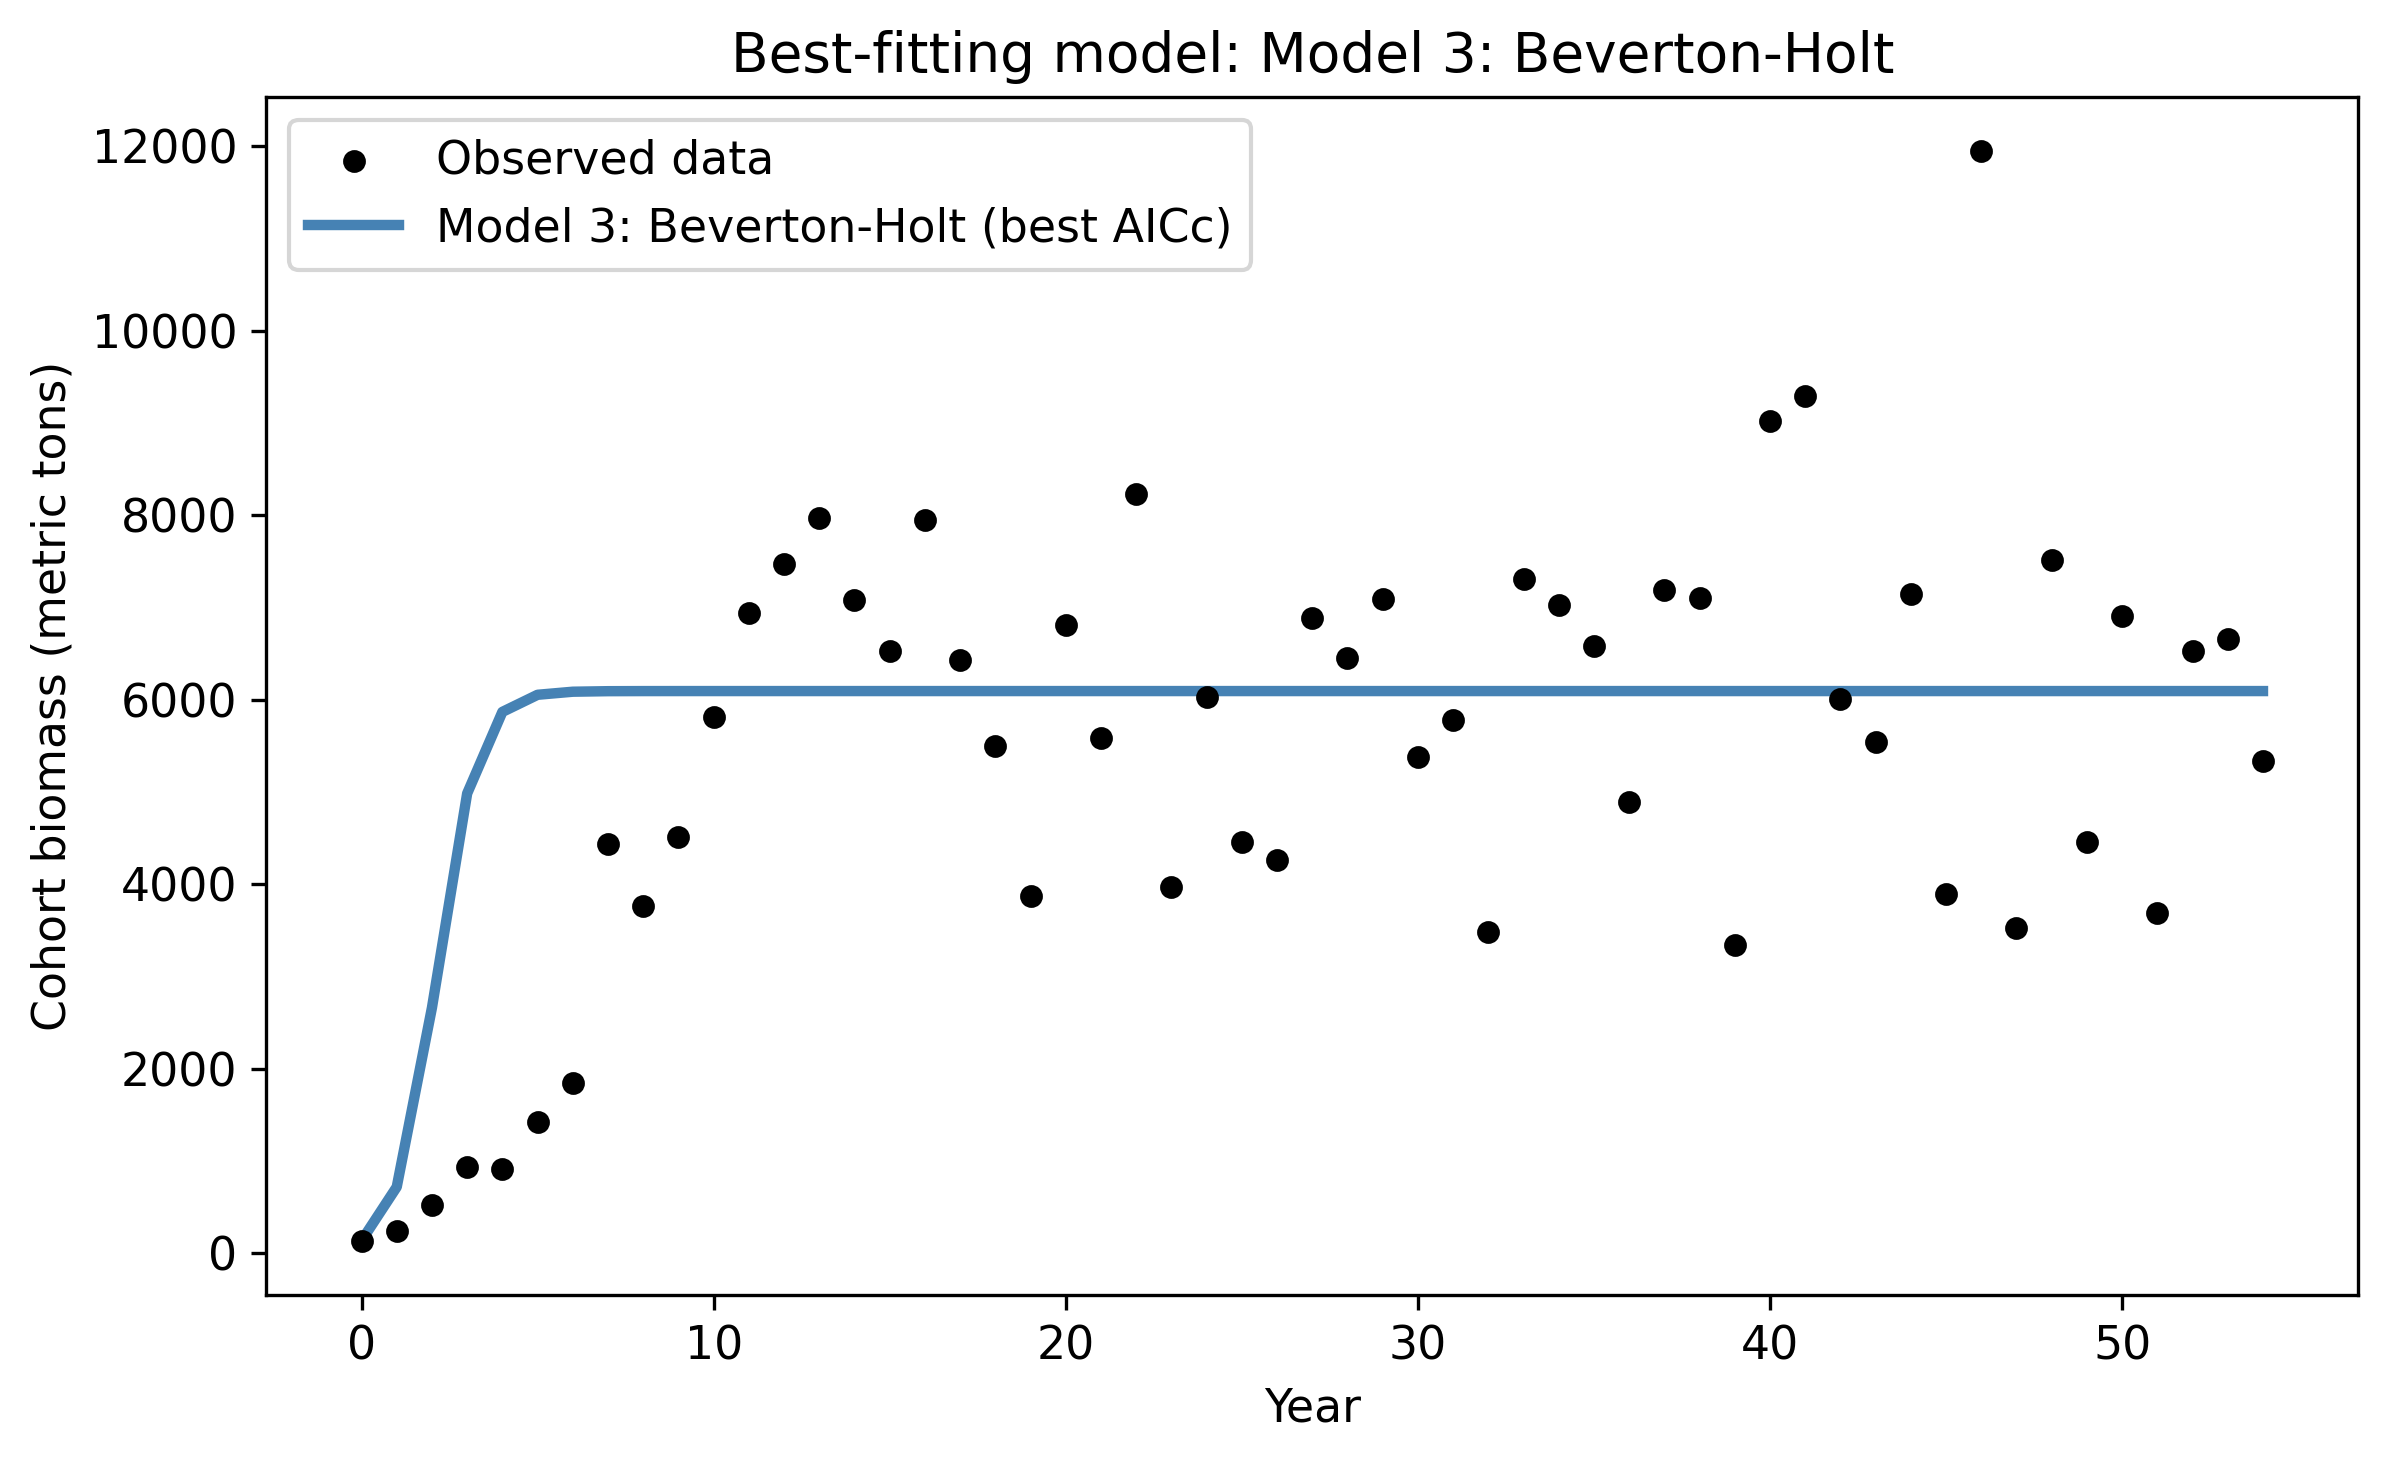

In [83]:
# Figure 5: Best-fitting model
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax.scatter(t_data, y_data, s=20, color='black', label='Observed data', zorder=5)
ax.plot(t_data, best_ypred, color='steelblue', lw=2.5, label=f'{best_name} (best AICc)')
ax.set_xlabel('Year')
ax.set_ylabel('Cohort biomass (metric tons)')
ax.set_title(f'Best-fitting model: {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('step4_best_model.png', bbox_inches='tight')
plt.show()